<a href="https://colab.research.google.com/github/swamyaswagat/leo-mec-handover-aware-optimization/blob/main/01_orbit_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q skyfield sgp4 matplotlib numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.4/370.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.7/235.7 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.2 MB/s eta 0:00:00


In [2]:
from skyfield.api import load, Topos
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [10]:
from skyfield.api import Topos
import numpy as np

ground = Topos(
"22.3149 N",
"87.3105 E"
)

times = ts.utc(
2026,
6,
24,
13,
0,
range(1800)   # 30 min
)

best_sat = None
best_peak = -999

for s in satellites[:300]:

    diff = s - ground

    topo = diff.at(times)

    alt = topo.altaz()[0]

    peak = alt.degrees.max()

    if peak > best_peak:

        best_peak = peak

        best_sat = s

print("Best peak elevation:", best_peak)
print("Satellite:", best_sat.name)

Best peak elevation: 58.08625980891461
Satellite: STARLINK-1012


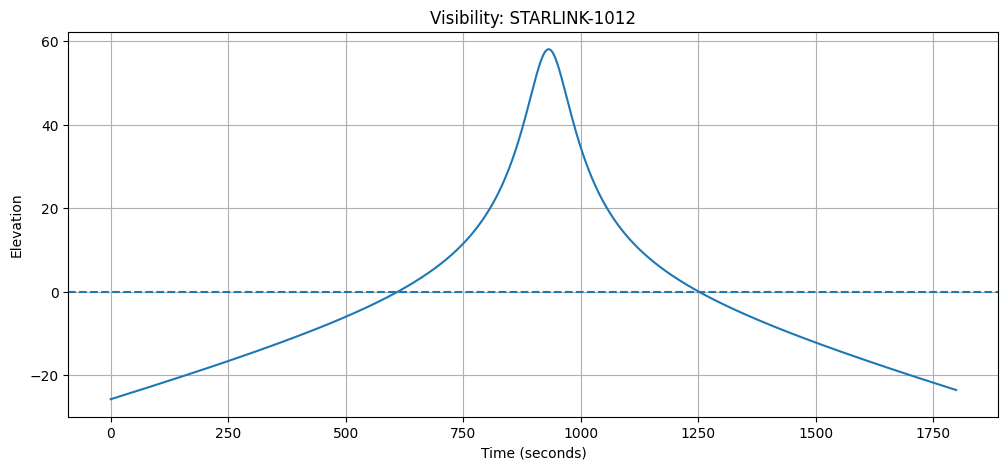

In [11]:
sat = best_sat

difference = sat - ground

topo = difference.at(times)

alt, az, distance = topo.altaz()

plt.figure(figsize=(12,5))

plt.plot(
range(1800),
alt.degrees
)

plt.axhline(
0,
linestyle="--"
)

plt.xlabel("Time (seconds)")

plt.ylabel("Elevation")

plt.title(
f"Visibility: {sat.name}"
)

plt.grid()

plt.show()

In [12]:
visible = alt.degrees > 0

indices = np.where(
visible
)[0]

if len(indices):

    rvt = indices[-1]

else:

    rvt = 0

print(
"RVT =",
rvt,
"seconds"
)

RVT = 1251 seconds


In [14]:
plt.savefig(
    "figure1_visibility_curve.png",
    dpi=300,
    bbox_inches="tight"
)

print("Saved")

Saved


<Figure size 640x480 with 0 Axes>

In [15]:
!ls

figure1_visibility_curve.png  gp.php  sample_data


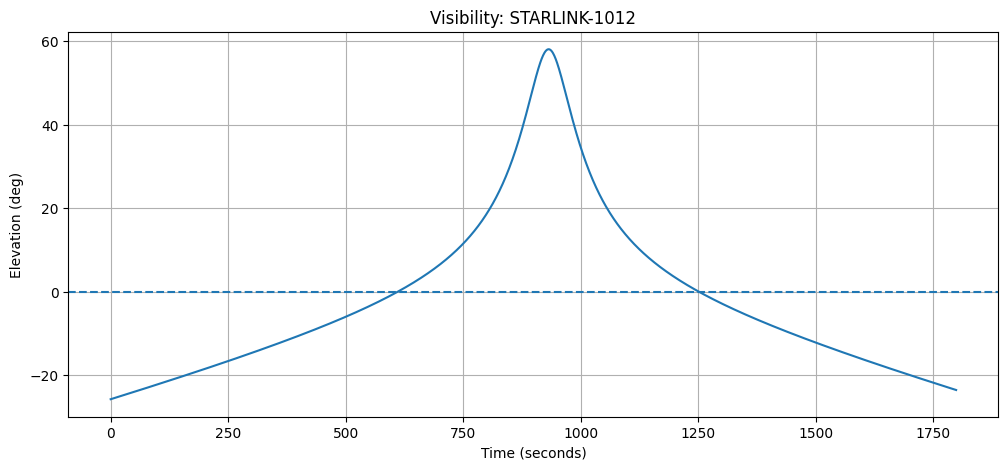

In [19]:
import os
import matplotlib.pyplot as plt

os.makedirs(
    "figures",
    exist_ok=True
)

plt.figure(
    figsize=(12,5)
)

plt.plot(
    range(1800),
    alt.degrees
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Time (seconds)"
)

plt.ylabel(
    "Elevation (deg)"
)

plt.title(
    f"Visibility: {sat.name}"
)

plt.grid()

# SAVE FIRST
plt.savefig(
    "figures/figure1_visibility_curve.png",
    dpi=300,
    bbox_inches="tight"
)

# THEN SHOW
plt.show()